<a href="https://colab.research.google.com/github/Ana-Beatriz-N/ProcessamentoDeImagens/blob/main/Quantizacao.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

In [2]:
upload = files.upload()

Saving minion.png to minion.png


array([[[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       ...,

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]]], dtype=uint8)
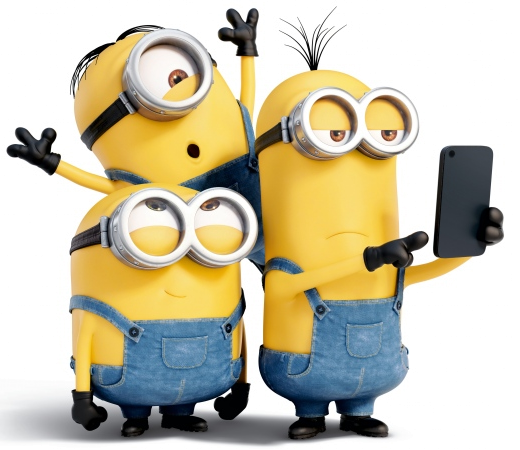

In [3]:
img = cv2.imread('minion.png')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img_hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
img_rgb

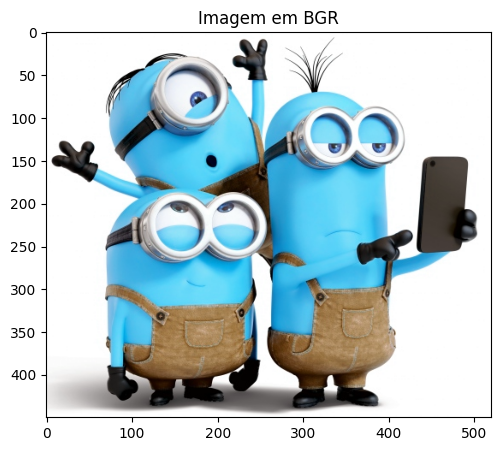

In [4]:
plt.figure(figsize=(8,5))
plt.imshow(img)
plt.title('Imagem em BGR')
plt.show()

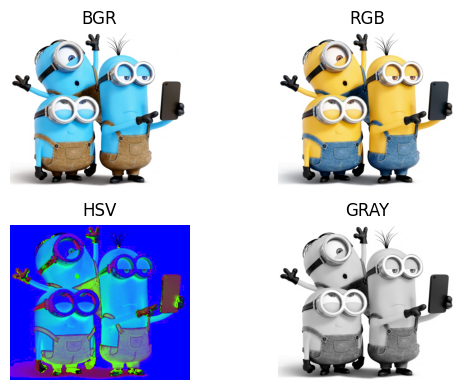

In [5]:
fig,  ax = plt.subplots(2, 2, figsize=(6, 4))

ax[0,0].imshow(img)
ax[0,0].set_title('BGR')
ax[0,0].axis('off')

ax[0,1].imshow(img_rgb)
ax[0,1].set_title('RGB')
ax[0,1].axis('off')

ax[1,0].imshow(img_hsv)
ax[1,0].set_title('HSV')
ax[1,0].axis('off')

ax[1,1].imshow(img_gray, cmap='gray')
ax[1,1].set_title('GRAY')
ax[1,1].axis('off')

plt.tight_layout()
plt.savefig('conversao_cores.png')
plt.show()

## Exercício — Quantização de Imagens
A partir da imagem convertida para tons de cinza (`img_gray`), serão geradas versões quantizadas com 1, 2, 4 e 8 bits.


In [7]:
def quantizar(imagem, bits):
    niveis = 2 ** bits
    quantizada = np.round(imagem.astype(np.float32) * (niveis - 1) / 255.0)
    quantizada = quantizada * (255.0 / (niveis - 1))
    return np.clip(quantizada, 0, 255).astype(np.uint8)

img_1bit = quantizar(img_gray, 1)
img_2bits = quantizar(img_gray, 2)
img_4bits = quantizar(img_gray, 4)
img_8bits = quantizar(img_gray, 8)


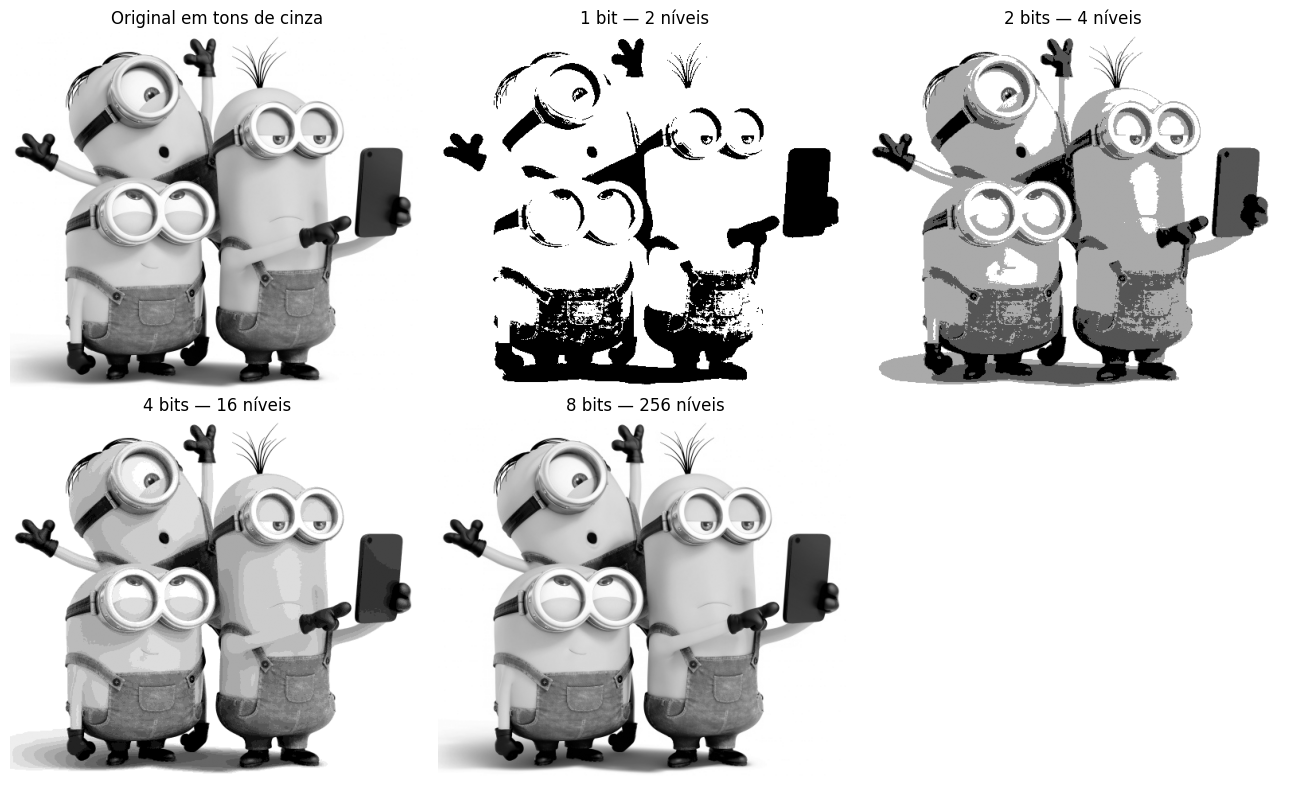

In [8]:
fig, ax = plt.subplots(2, 3, figsize=(13, 8))
ax = ax.ravel()

ax[0].imshow(img_gray, cmap="gray", vmin=0, vmax=255)
ax[0].set_title("Original em tons de cinza")
ax[0].axis("off")

imagens = [(img_1bit, "1 bit — 2 níveis"),
           (img_2bits, "2 bits — 4 níveis"),
           (img_4bits, "4 bits — 16 níveis"),
           (img_8bits, "8 bits — 256 níveis")]

for eixo, (imagem, titulo) in zip(ax[1:5], imagens):
    eixo.imshow(imagem, cmap="gray", vmin=0, vmax=255)
    eixo.set_title(titulo)
    eixo.axis("off")

ax[5].axis("off")
plt.tight_layout()
plt.savefig("quantizacao.png", dpi=200, bbox_inches="tight")
plt.show()


Com menos bits detalhes são perdidos e as transições entre tons ficam mais visíveis. Por exemplo, em 1 bit existem apenas dois níveis, preto e branco, enquanto em 8 bits tem 256 níveis, permitindo representar mais detalhes.